# Spectral Bounds for Factorable Functions

Given a factorable, multivariate function $f:\mathbf{X}\to\mathbb{R}$, that is twice-continuously differentiable on the interval domain $\mathbf{X}\in\mathbb{IR}^n$, M&ouml;nnigmann's technique ([M&ouml;nnigmann, 2008](https://doi.org/10.1007/BF01580665); [M&ouml;nnigmann, 2011](https://doi.org/10.1137/10078760X); [Schulze Darup et al., 2014](https://doi.org/10.1007/s10898-013-0099-1)) provides a means for computing spectral bounds of its Hessian matrix $\nabla^2f(\mathbf{x})$ at any point $\mathbf{x}\in \mathbf{X}$ without actually computing $\nabla^2f(\mathbf{x})$. Applications of this technique are in determining whether a function is convex or concave on a particular domain, as well as in constructing convex/concave relaxations for complete search approaches in global optimization. Alternative techniques for determining spectral bounds include the interval variant of Gershgorin's circle criterion ([Adjiman et al., 1998](https://doi.org/10.1016/S0098-1354(98)00027-1)) as well as Hertz's exact method ([Hertz, 1992](https://doi.org/10.1109/9.126593)) and Rohn's approximate method ([Rohn et al, 1994](https://doi.org/10.1137/S0895479891219216)), which relies on an interval enclosure of the set of all possible Hessian matrices $[\nabla^2f] \supseteq \{\nabla^2f(\mathbf{x}) \mid \mathbf{x}\in \mathbf{X}\}$. The module `Specbnd` in PyMC provides an implementation of these spectral bounding techniques. 

## Computing Spectral Bounds in PyMC

Suppose we want to compute spectral bounds on the real-valued function $f(x,y)=x(\exp(x)-y)^2$ for $(x,y)\in [-2,1]\times[-1,2]$. 

We start by importing the PyMC library:

In [1]:
import pymc

We proceed by defining the ranges of both variables $x$ and $y$ (cf. [Other notebook](./interval.ipynb)), then initialize spectral bound variables for $x$ and $y$ of type `pymc.Specbnd` with indices `0` and `1`, respectively, out of $N=2$ variables:

In [2]:
xI, yI = pymc.Interval(-2,1), pymc.Interval(-1,2)
N = 2
xSB, ySB = pymc.Specbnd( xI, 0, N ), pymc.Specbnd( yI, 1, N )
#print(xSB, ySB)

With operator overloading, we can simply compute spectral bounds for $f(x,y)$ on $[-2,1]\times[-1,2]$ as:

In [3]:
def f( x, y ):
    return x*(np.exp(x)-y)**2
    #return 1.+x-np.sin(2.*x+3.*y)-np.cos(3.*x-5.*y)

def fSB( x, y ):
    return x*(pymc.exp(x)-y)**2
    #return 1.+x-pymc.sin(2.*x+3.*y)-pymc.cos(3.*x-5.*y)


In [4]:
zSB = fSB( xSB, ySB )
print( "Spectral bounds:", zSB )

Spectral bounds: [ -1.0566210884129676e+02 :  7.8746628211942138e+01 ]


Lower and upper bounds on the spectrum can be retrieved with the field `SI`, then the fields `l` and `u`: 

In [5]:
print("Spectral lower/upper bounds:", zSB.SI.l, zSB.SI.u)

Spectral lower/upper bounds: -105.66210884129676 78.74662821194214


Spectral bounds can also be propagated through an expression tree (DAG):

In [6]:
DAG  = pymc.FFGraph()
X, Y = DAG.add_var( "x" ), DAG.add_var( "y" )

F = fSB( X, Y )
print( "f(", X.str(), ",", Y.str(), ") = ", F.str() )

[zSB2] = DAG.eval( [F], [X,Y], [xSB,ySB] )
print("Spectral lower/upper bounds:", zSB2.SI.l, zSB2.SI.u)

f( x , y ) =  x * SQR( EXP( x ) - y )
Spectral lower/upper bounds: -105.66210884129676 78.74662821194214


Spectral bounds can also be computed from an interval Hessian matrix of $f(x,y)$ on $[-2,1]\times[-1,2]$:

In [7]:
DF   = DAG.bdiff( [F], [X,Y] )
for r,c,d in zip(DF[0],DF[1],DF[2]):
     print( "df[", c, "](", X.str(), ",", Y.str(), ") = ", d.str() )

D2F  = DAG.bdiff( DF[2], [X,Y] )
for r,c,d in zip(D2F[0],D2F[1],D2F[2]):
     print( "d2f[", c, ",", r, "](", X.str(), ",", Y.str(), ") = ", d.str() )

d2fval = DAG.eval( D2F[2], [X,Y], [0.,0.] )
zSB_ref = pymc.Specbnd.spectrum( N, d2fval, D2F[0], D2F[1] )
print("\nSpectral bounds at (0,0):", zSB_ref)

df[ 0 ]( x , y ) =  SQR( EXP( x ) - y ) + EXP( x ) * x * ( EXP( x ) - y ) * 2
df[ 1 ]( x , y ) =  ( - x * ( EXP( x ) - y ) * 2 )
d2f[ 0 , 0 ]( x , y ) =  EXP( x ) * ( x * ( EXP( x ) - y ) * 2 + ( EXP( x ) - y ) * 2 + ( x * EXP( x ) ) * 2 ) + EXP( x ) * ( EXP( x ) - y ) * 2
d2f[ 1 , 0 ]( x , y ) =  ( - ( ( EXP( x ) - y ) * 2 + ( x * EXP( x ) ) * 2 ) )
d2f[ 0 , 1 ]( x , y ) =  EXP( x ) * ( - x ) * 2 + ( - ( EXP( x ) - y ) * 2 )
d2f[ 1 , 1 ]( x , y ) =  ( - ( - x ) * 2 )

Spectral bounds at (0,0): (-0.8284271247461902, 4.82842712474619)


In [8]:
D2FI = DAG.eval( D2F[2], [X,Y], [xI,yI] )
print("Interval Hessian matrix:", D2FI)

zSB_Gersh = pymc.Specbnd.spectral_bound_gershgorin( N, D2FI, D2F[0], D2F[1] )
print("\nGershgorin's spectral bounds:", zSB_Gersh)

zSB_Rohn = pymc.Specbnd.spectral_bound_rohn( N, D2FI, D2F[0], D2F[1] )
print("\nRohn's spectral bounds:", zSB_Rohn)

zSB_Hertz = pymc.Specbnd.spectral_bound_hertz( N, D2FI, D2F[0], D2F[1] )
print("\nHertz's spectral bounds:", zSB_Hertz)

Interval Hessian matrix: [[ -9.0260312968267996e+01 :  7.5482200770406706e+01 ], [ -1.2873127313836182e+01 :  1.4602456747362957e+01 ], [ -1.2873127313836182e+01 :  1.4602456747362957e+01 ], [ -4.0000000000000000e+00 :  2.0000000000000000e+00 ]]

Gershgorin's spectral bounds: (-104.86276971563095, 90.08465751776967)

Rohn's spectral bounds: (-92.67210392017964, 84.283047821249)

Hertz's spectral bounds: (-92.66522144954823, 78.27766827588141)


A 3d plot showing bounds on the spectrum of $f$ over the domain $[-2,1]\times[-1,2]$ along with the computed bounds is constructed below. 

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

M = 128
mat_x = np.outer(np.linspace(xI.l, xI.u, M), np.ones(M))
mat_y = np.outer(np.ones(M), np.linspace(yI.l, yI.u, M))

mat_d2fmin  = np.ndarray(shape=(M,M))
mat_d2fmax  = np.ndarray(shape=(M,M))

for i,j in product(range(M),range(M)):
    d2fval  = DAG.eval( D2F[2], [X,Y], [mat_x[i,j],mat_y[i,j]] )
    mat_d2fmin[i,j], mat_d2fmax[i,j] = pymc.Specbnd.spectrum( N, d2fval, D2F[0], D2F[1] )
    
mat_d2fl = np.outer(np.ones(M), np.ones(M)) * zSB.SI.l
mat_d2fu = np.outer(np.ones(M), np.ones(M)) * zSB.SI.u

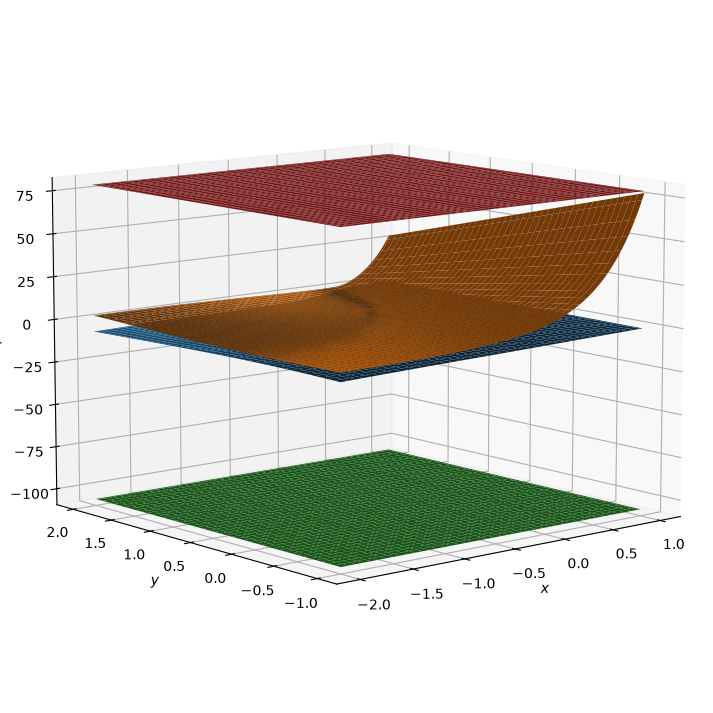

In [10]:
fig = plt.figure(figsize =(14, 9))
ax = plt.axes(projection ='3d')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('spectrum')

ax.plot_surface(mat_x, mat_y, mat_d2fmin)
ax.plot_surface(mat_x, mat_y, mat_d2fmax)
ax.plot_surface(mat_x, mat_y, mat_d2fl)
ax.plot_surface(mat_x, mat_y, mat_d2fu)
ax.view_init(elev=10, azim=230)

plt.show()

A 3d plot showing the resulting convex underestimator and concave overestimator of the function $f$ over the domain $[-2,1]\times[-1,2]$ is shown below. 

In [11]:
alphal, alphau = max(0,-0.5*zSB.SI.l), min(0,-0.5*zSB.SI.u)
print( alphal, alphau )

mat_f   = np.ndarray(shape=(M,M))
mat_fcv = np.ndarray(shape=(M,M))
mat_fcc = np.ndarray(shape=(M,M))

for i,j in product(range(M),range(M)):
    [mat_f[i,j]] = DAG.eval( [F], [X,Y], [mat_x[i,j],mat_y[i,j]] )
    mat_fcv[i,j] = mat_f[i,j] + alphal*((mat_x[i,j]-xI.u)*(mat_x[i,j]-xI.l)+(mat_y[i,j]-yI.u)*(mat_y[i,j]-yI.l))
    mat_fcc[i,j] = mat_f[i,j] + alphau*((mat_x[i,j]-xI.u)*(mat_x[i,j]-xI.l)+(mat_y[i,j]-yI.u)*(mat_y[i,j]-yI.l))

52.83105442064838 -39.37331410597107


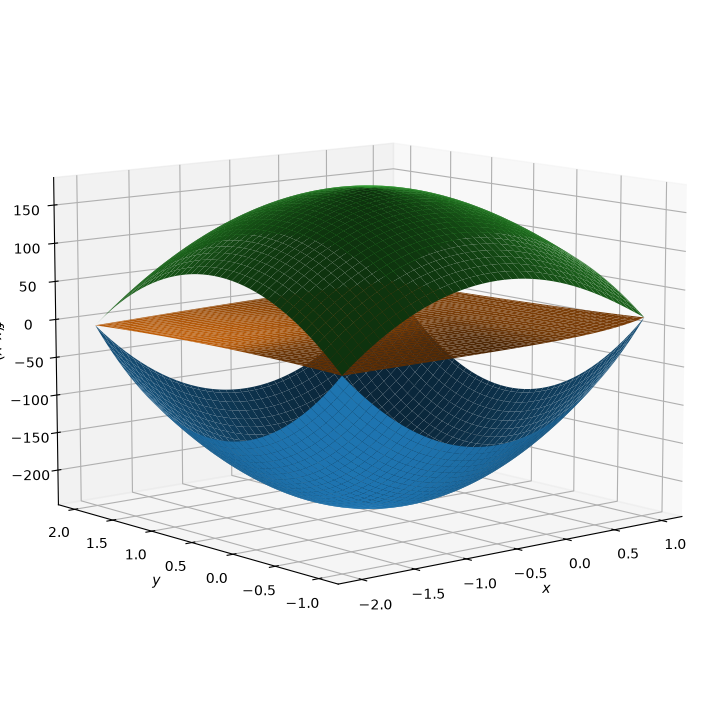

In [12]:
fig = plt.figure(figsize =(14, 9))
ax = plt.axes(projection ='3d')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$f(x,y)$')

ax.plot_surface(mat_x, mat_y, mat_fcv)
ax.plot_surface(mat_x, mat_y, mat_f)
ax.plot_surface(mat_x, mat_y, mat_fcc)
ax.view_init(elev=10, azim=230)

plt.show()